# Logistic Regression and SVM

## 1. What is a classification?

Classification is a **supervised** learning task:

$$
\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad y_i \in \{0, 1, \dots, K-1\}
$$

We already know the correct label during training and want a rule

$$
\hat{y} = f(x)
$$

that generalizes to new objects.

For binary classification, we often care about

$$
P(y=1 \mid x)
$$

Typical examples: spam vs not spam, churn vs stay, benign vs malignant.


In [1]:
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_breast_cancer,
    make_classification,
    make_moons,
)
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC

warnings.filterwarnings('ignore', category=ConvergenceWarning)
np.random.seed(42)

ink    = '#2f2a34'
paper  = '#f6f1e7'
panel  = '#efe4d6'
grid_c = '#ccbda8'

sns.set_theme(
    context='talk',
    style='ticks',
    palette=['#ff6b6b','#1982c4','#ffd166','#2a9d8f','#6a4c93'],
    rc={
        'figure.facecolor': paper,
        'axes.facecolor': panel,
        'axes.edgecolor': ink,
        'axes.labelcolor': ink,
        'text.color': ink,
        'xtick.color': ink,
        'ytick.color': ink,
        'grid.color': grid_c,
        'grid.linestyle': ':',
        'grid.alpha': 0.55,
        'axes.grid': True,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.titlelocation': 'left',
        'axes.titleweight': 'bold',
        'axes.titlepad': 14,
        'legend.frameon': True,
        'legend.facecolor': '#fbf7f0',
        'legend.edgecolor': grid_c,
    },
)

surface_cmap = sns.blend_palette(
    ['#1f2041','#4b3f72','#417b5a','#f4d35e','#ee964b'], as_cmap=True
)
cool_cmap = sns.blend_palette(['#e0fbfc','#4ea8de','#293241'], as_cmap=True)
class_colors = ['#ff6b6b','#1982c4','#6a4c93','#2a9d8f']


def metric_frame(y_true, y_pred, y_score=None):
    rows = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_score is not None:
        rows['roc_auc'] = roc_auc_score(y_true, y_score)
    return pd.DataFrame({'metric': list(rows.keys()), 'value': list(rows.values())})


def make_grid(X, n=300, padding=1.0):
    x0_min, x0_max = X[:, 0].min() - padding, X[:, 0].max() + padding
    x1_min, x1_max = X[:, 1].min() - padding, X[:, 1].max() + padding
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, n),
        np.linspace(x1_min, x1_max, n),
    )
    return xx, yy, np.c_[xx.ravel(), yy.ravel()]


def final_estimator(model):
    return model.named_steps['model'] if isinstance(model, Pipeline) else model


def scaler_step(model):
    if isinstance(model, Pipeline):
        return model.named_steps.get('scaler')
    return None


def score_on_grid(model, grid):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(grid)[:, 1]
    scores = model.decision_function(grid)
    mn, mx = scores.min(), scores.max()
    return (scores - mn) / (mx - mn)


def plot_surface(ax, model, X, y, title, show_support=False):
    xx, yy, grid = make_grid(X)
    z = score_on_grid(model, grid).reshape(xx.shape)
    ax.contourf(xx, yy, z, levels=28, cmap=surface_cmap, alpha=0.94)
    ax.contour(xx, yy, z, levels=[0.5], colors='#fffaf1', linewidths=2.2)
    sns.scatterplot(
        x=X[:, 0], y=X[:, 1], hue=y,
        palette=class_colors[:len(np.unique(y))],
        s=60, edgecolor='#2b1d26', linewidth=0.4, legend=False, ax=ax,
    )
    if show_support and hasattr(final_estimator(model), 'support_vectors_'):
        sv = final_estimator(model).support_vectors_
        sc = scaler_step(model)
        if sc is not None:
            sv = sc.inverse_transform(sv)
        ax.scatter(sv[:, 0], sv[:, 1], s=220,
                   facecolors='none', edgecolors='#fffaf1', linewidths=1.8)
    ax.set_title(title)
    ax.set_xlabel('feature 1')
    ax.set_ylabel('feature 2')


def annotate_bars(ax, offset=None, fmt='{:.3f}'):
    ymin, ymax = ax.get_ylim()
    delta = (ymax - ymin) * 0.02 if offset is None else offset
    for patch in ax.patches:
        value = patch.get_height()
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            value + delta,
            fmt.format(value),
            ha='center', va='bottom', fontsize=10,
        )


print("Theme loaded. Notebook ready.")


Theme loaded. Notebook ready.


In [2]:
X_lin, y_lin = make_classification(
    n_samples=500,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    class_sep=1.8,
    flip_y=0.04,
    random_state=42,
)

X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(
    X_lin, y_lin, test_size=0.25, stratify=y_lin, random_state=42
)

print(f'Train size: {X_train_lin.shape}')
print(f'Test size:  {X_test_lin.shape}')

Train size: (375, 2)
Test size:  (125, 2)


In [3]:
logreg_with = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=1.0, max_iter=2000)),
])

svm_lin_with = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='linear', C=1.0)),
])

svm_rbf_with = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, random_state=42)),
])


logreg_with.fit(X_train_lin, y_train_lin)
svm_lin_with.fit(X_train_lin, y_train_lin)
svm_rbf_with.fit(X_train_lin, y_train_lin)

print('Models with scaler trained')

Models with scaler trained


In [4]:
logreg_without = Pipeline([
   ('model',SVC(kernel = 'rbf', C=2.0, gamma='scale', probability=True, random_state = 42))
])

svm_lin_without = Pipeline([
   ('model',  SVC(kernel='linear', C=1.0))
])

svm_rbf_without = Pipeline([
    ('model',  SVC(kernel='rbf', C=2.0, gamma='scale', probability=True, random_state=42))
])

logreg_without.fit(X_train_lin,y_train_lin)
svm_lin_without.fit(X_train_lin,y_train_lin)
svm_rbf_without.fit(X_train_lin,y_train_lin)

print('Models without scaler trained')

Models without scaler trained


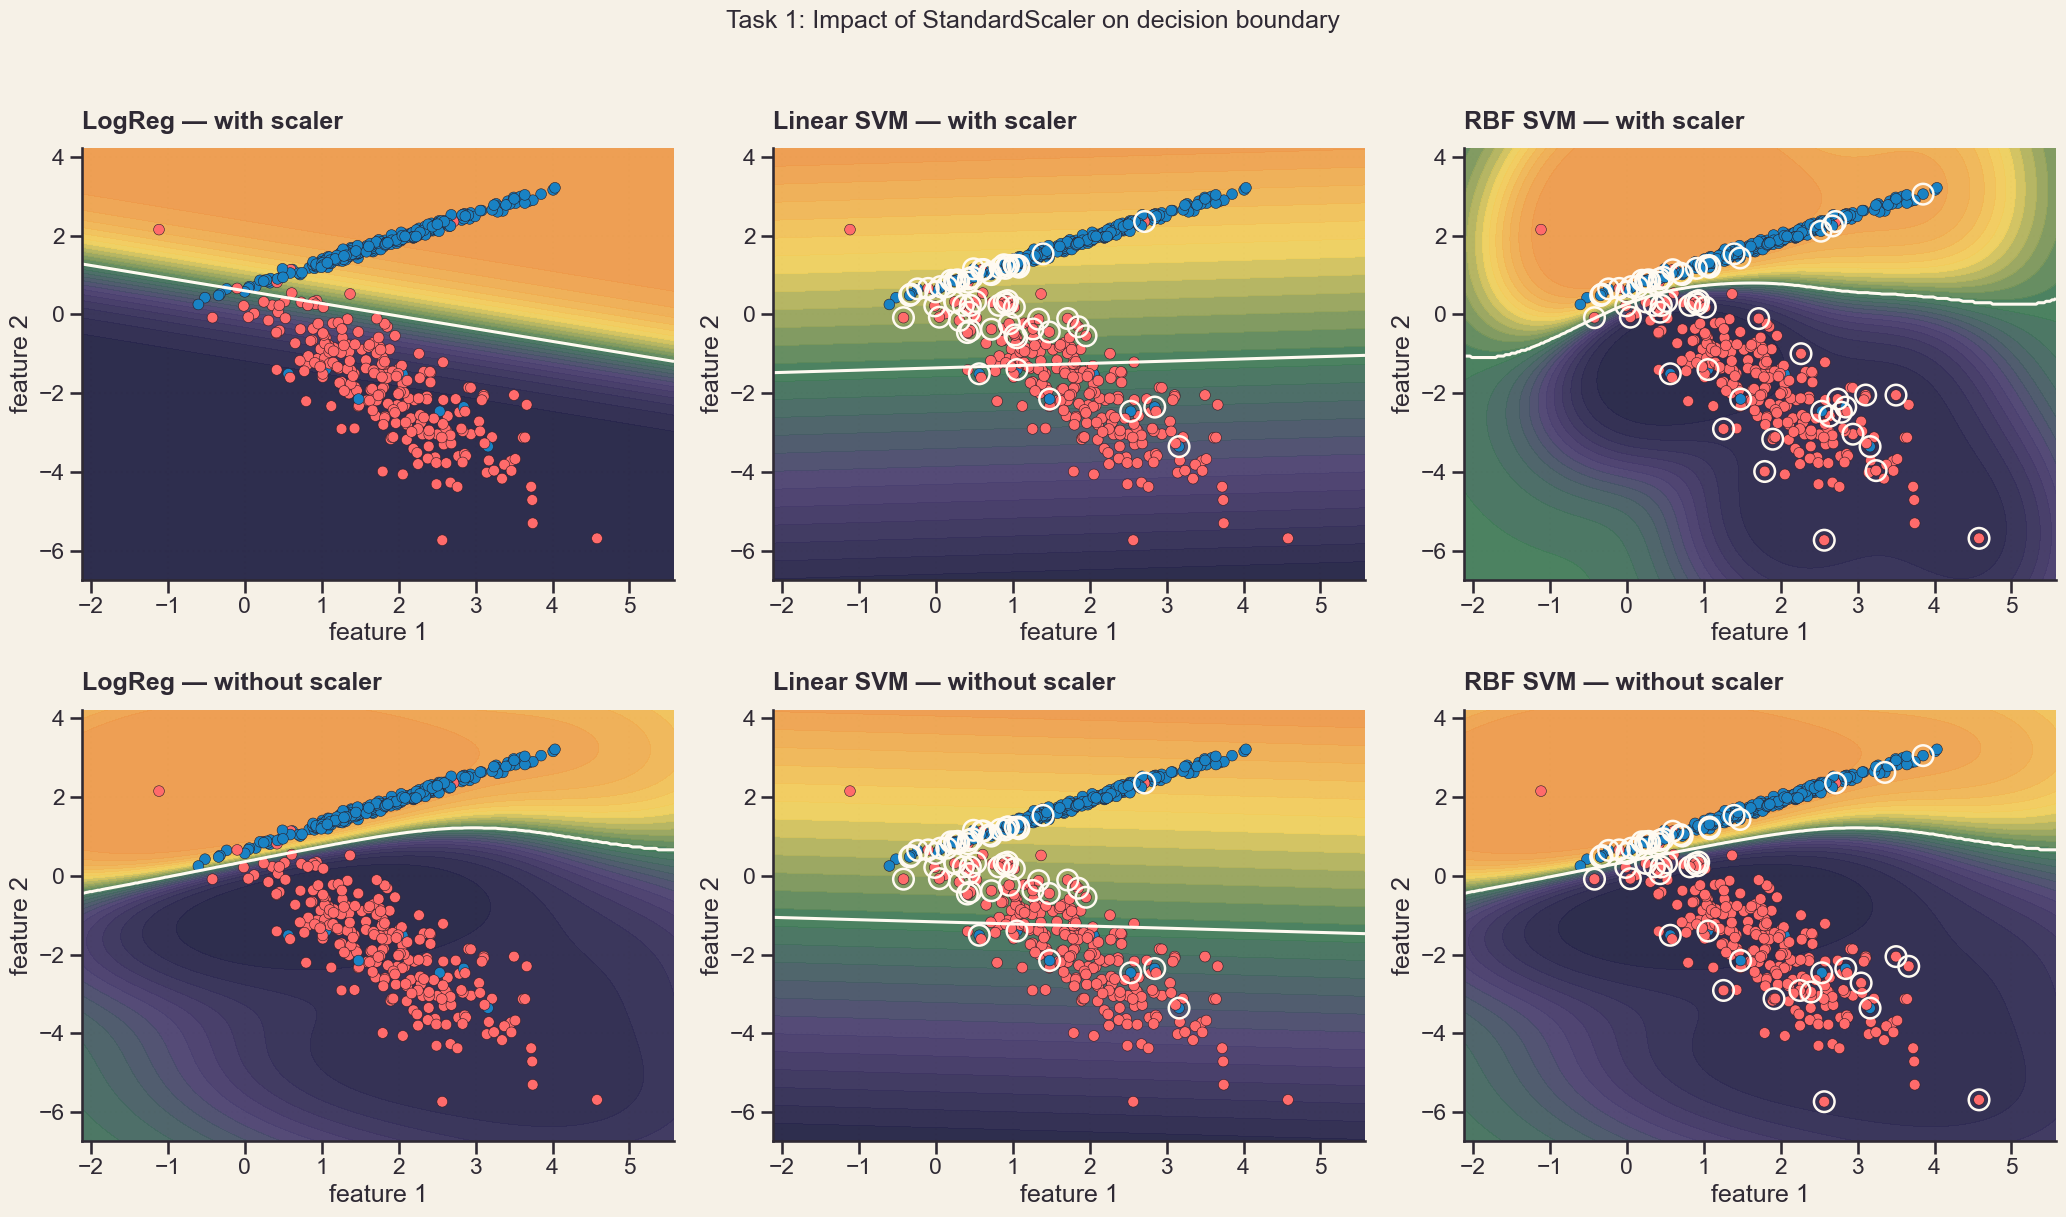

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(21, 12))

plot_surface(axes[0][0], logreg_with,   X_lin, y_lin, 'LogReg — with scaler')
plot_surface(axes[0][1], svm_lin_with,  X_lin, y_lin, 'Linear SVM — with scaler',  show_support=True)
plot_surface(axes[0][2], svm_rbf_with,  X_lin, y_lin, 'RBF SVM — with scaler',     show_support=True)

plot_surface(axes[1][0], logreg_without,   X_lin, y_lin, 'LogReg — without scaler')
plot_surface(axes[1][1], svm_lin_without,  X_lin, y_lin, 'Linear SVM — without scaler', show_support=True)
plot_surface(axes[1][2], svm_rbf_without,  X_lin, y_lin, 'RBF SVM — without scaler',    show_support=True)

fig.suptitle('Task 1: Impact of StandardScaler on decision boundary', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()


In [6]:
rows = []

for model, label in [
    (logreg_with,    'LogReg with scaler'),
    (logreg_without, 'LogReg without scaler'),
    (svm_lin_with,   'LinearSVM with scaler'),
    (svm_lin_without,'LinearSVM without scaler'),
    (svm_rbf_with,   'RBF SVM with scaler'),
    (svm_rbf_without,'RBF SVM without scaler'),
]:
    pred = model.predict(X_test_lin)
    rows.append(
        metric_frame(y_test_lin, pred).assign(model=label)
    )

result = pd.concat(rows, ignore_index=True)
result.pivot(index='metric', columns='model', values='value').round(3)


model,LinearSVM with scaler,LinearSVM without scaler,LogReg with scaler,LogReg without scaler,RBF SVM with scaler,RBF SVM without scaler
metric,,,,,,
accuracy,0.968,0.952,0.952,0.984,0.984,0.984
f1,0.969,0.952,0.952,0.984,0.984,0.984
precision,0.954,0.952,0.952,0.984,0.984,0.984
recall,0.984,0.952,0.952,0.984,0.984,0.984


In [7]:
logreg_thresh = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(C=1.0, max_iter=2000)),
])
logreg_thresh.fit(X_train_lin, y_train_lin)

proba_thresh = logreg_thresh.predict_proba(X_test_lin)[:, 1]

print('First 10 probabilities:')
print(proba_thresh[:10].round(3))
print('All between 0 and 1? ', proba_thresh.min().round(3), '—', proba_thresh.max().round(3))

First 10 probabilities:
[0.758 0.003 0.836 0.993 0.276 0.963 0.99  0.894 0.031 0.003]
All between 0 and 1?  0.001 — 0.999


In [8]:
thresholds = np.linspace(0.05, 0.95, 37)
threshold_rows = []

for threshold in thresholds:
    pred_t = (proba_thresh >= threshold).astype(int)
    threshold_rows.append({
        'threshold': threshold,
        'precision': precision_score(y_test_lin, pred_t, zero_division=0),
        'recall':    recall_score(y_test_lin, pred_t, zero_division=0),
        'f1':        f1_score(y_test_lin, pred_t, zero_division=0),
    })

threshold_frame = pd.DataFrame(threshold_rows)
threshold_frame.head()

,threshold,precision,recall,f1
0,0.050,0.656250,1.000000,0.792453
1,0.075,0.738095,0.984127,0.843537
2,0.100,0.765432,0.984127,0.861111
3,0.125,0.784810,0.984127,0.873239
4,0.150,0.805195,0.984127,0.885714


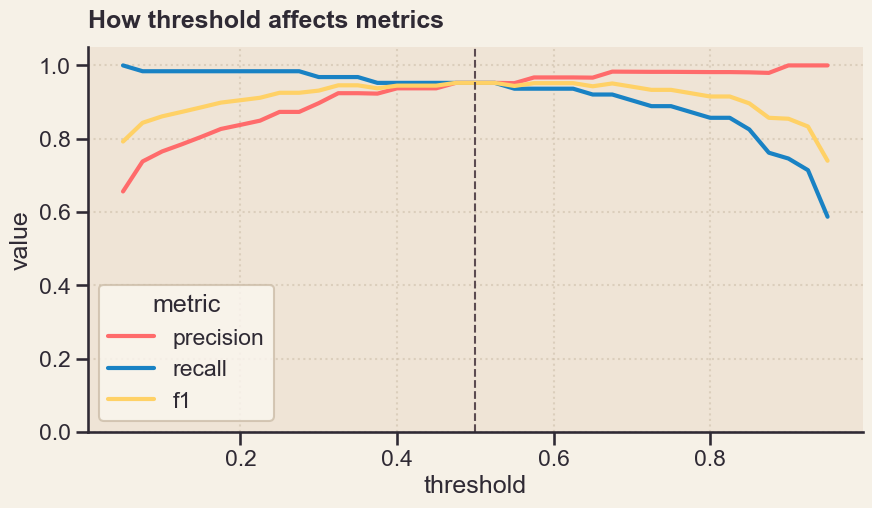

In [9]:
threshold_plot = threshold_frame.melt(
    id_vars='threshold',
    var_name='metric',
    value_name='value'
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=threshold_plot,
    x='threshold', y='value', hue='metric',
    linewidth=3, ax=ax,
)
ax.axvline(0.5, color='#5c4b51', linestyle='--', linewidth=1.5, label='default=0.5')
ax.set_title('How threshold affects metrics')
ax.set_ylim(0, 1.05)
plt.show()


In [10]:
best_recall_row = threshold_frame.sort_values('recall', ascending=False).head(1)
print('Best threshold for Recall:')
print(best_recall_row.round(3))

best_threshold_recall = best_recall_row['threshold'].values[0]
print(f'\nOptimal threshold: {best_threshold_recall:.3f}')

Best threshold for Recall:
   threshold  precision  recall     f1
0       0.05      0.656     1.0  0.792

Optimal threshold: 0.050


In [11]:
pred_default = (proba_thresh >= 0.5).astype(int)
best_thresh_value = best_recall_row['threshold'].values[0]

pred_best_recall =(proba_thresh >= best_threshold_recall).astype(int)

comparison = pd.concat([
    metric_frame(y_test_lin, pred_default).assign(threshold='0.5 (default)'),
    metric_frame(y_test_lin, pred_best_recall).assign(threshold=f'{best_threshold_recall:.2f} (max recall)'),
], ignore_index=True)

comparison.pivot(index='metric', columns='threshold', values='value').round(3)

threshold,0.05 (max recall),0.5 (default)
metric,,
accuracy,0.736,0.952
f1,0.792,0.952
precision,0.656,0.952
recall,1.000,0.952


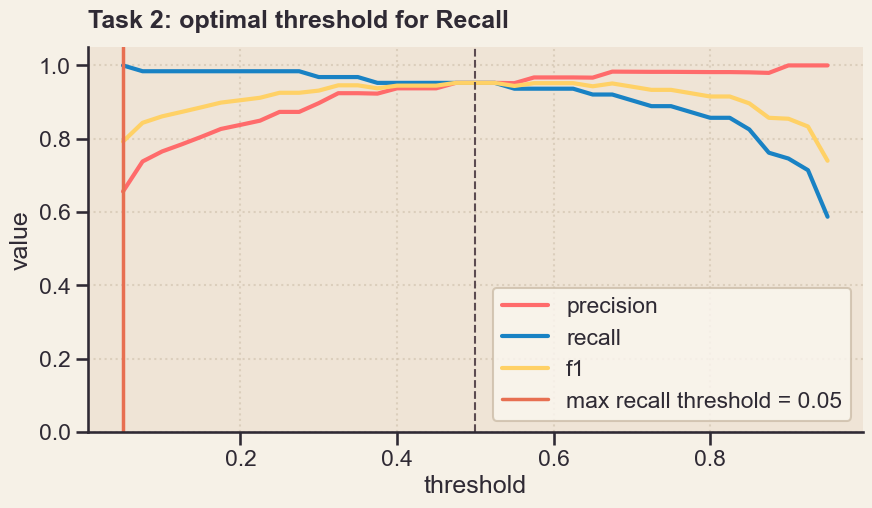

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(
    data=threshold_plot,
    x='threshold', y='value', hue='metric',
    linewidth=3, ax=ax,
)

ax.axvline(0.5, color='#5c4b51', linestyle='--', linewidth=1.5)
ax.axvline(best_threshold_recall, color='#e76f51', linestyle='-', linewidth=2.5,
           label=f'max recall threshold = {best_threshold_recall:.2f}')

ax.set_title('Task 2: optimal threshold for Recall')
ax.set_ylim(0, 1.05)
ax.legend()
plt.show()

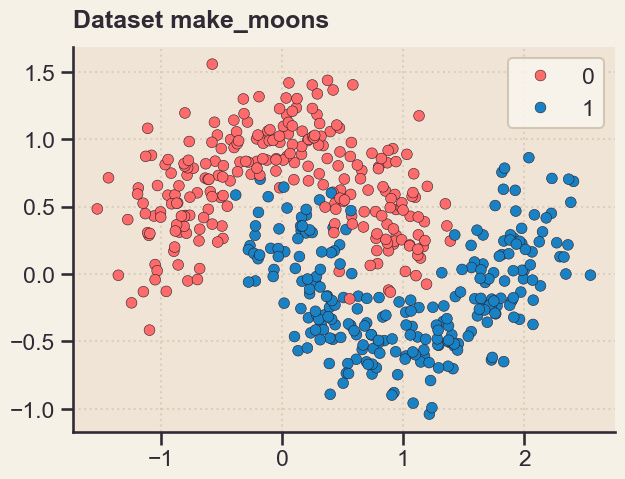

In [13]:
X_moon, y_moon = make_moons(n_samples=500, noise=0.22, random_state=42)

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_moon, y_moon, test_size=0.25, stratify=y_moon, random_state=42
)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    x=X_moon[:, 0], y=X_moon[:, 1], hue=y_moon,
    palette=class_colors[:2], s=60,
    edgecolor='#2b1d26', linewidth=0.4, ax=ax,
)
ax.set_title('Dataset make_moons')
plt.show()

In [14]:
C_fixed = 10.0 

gamma_values = [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]

print(f'Number of gamma values: {len(gamma_values)}')
print(f'Values: {gamma_values}')

Number of gamma values: 8
Values: [0.01, 0.05, 0.1, 0.5, 1, 5, 10, 50]


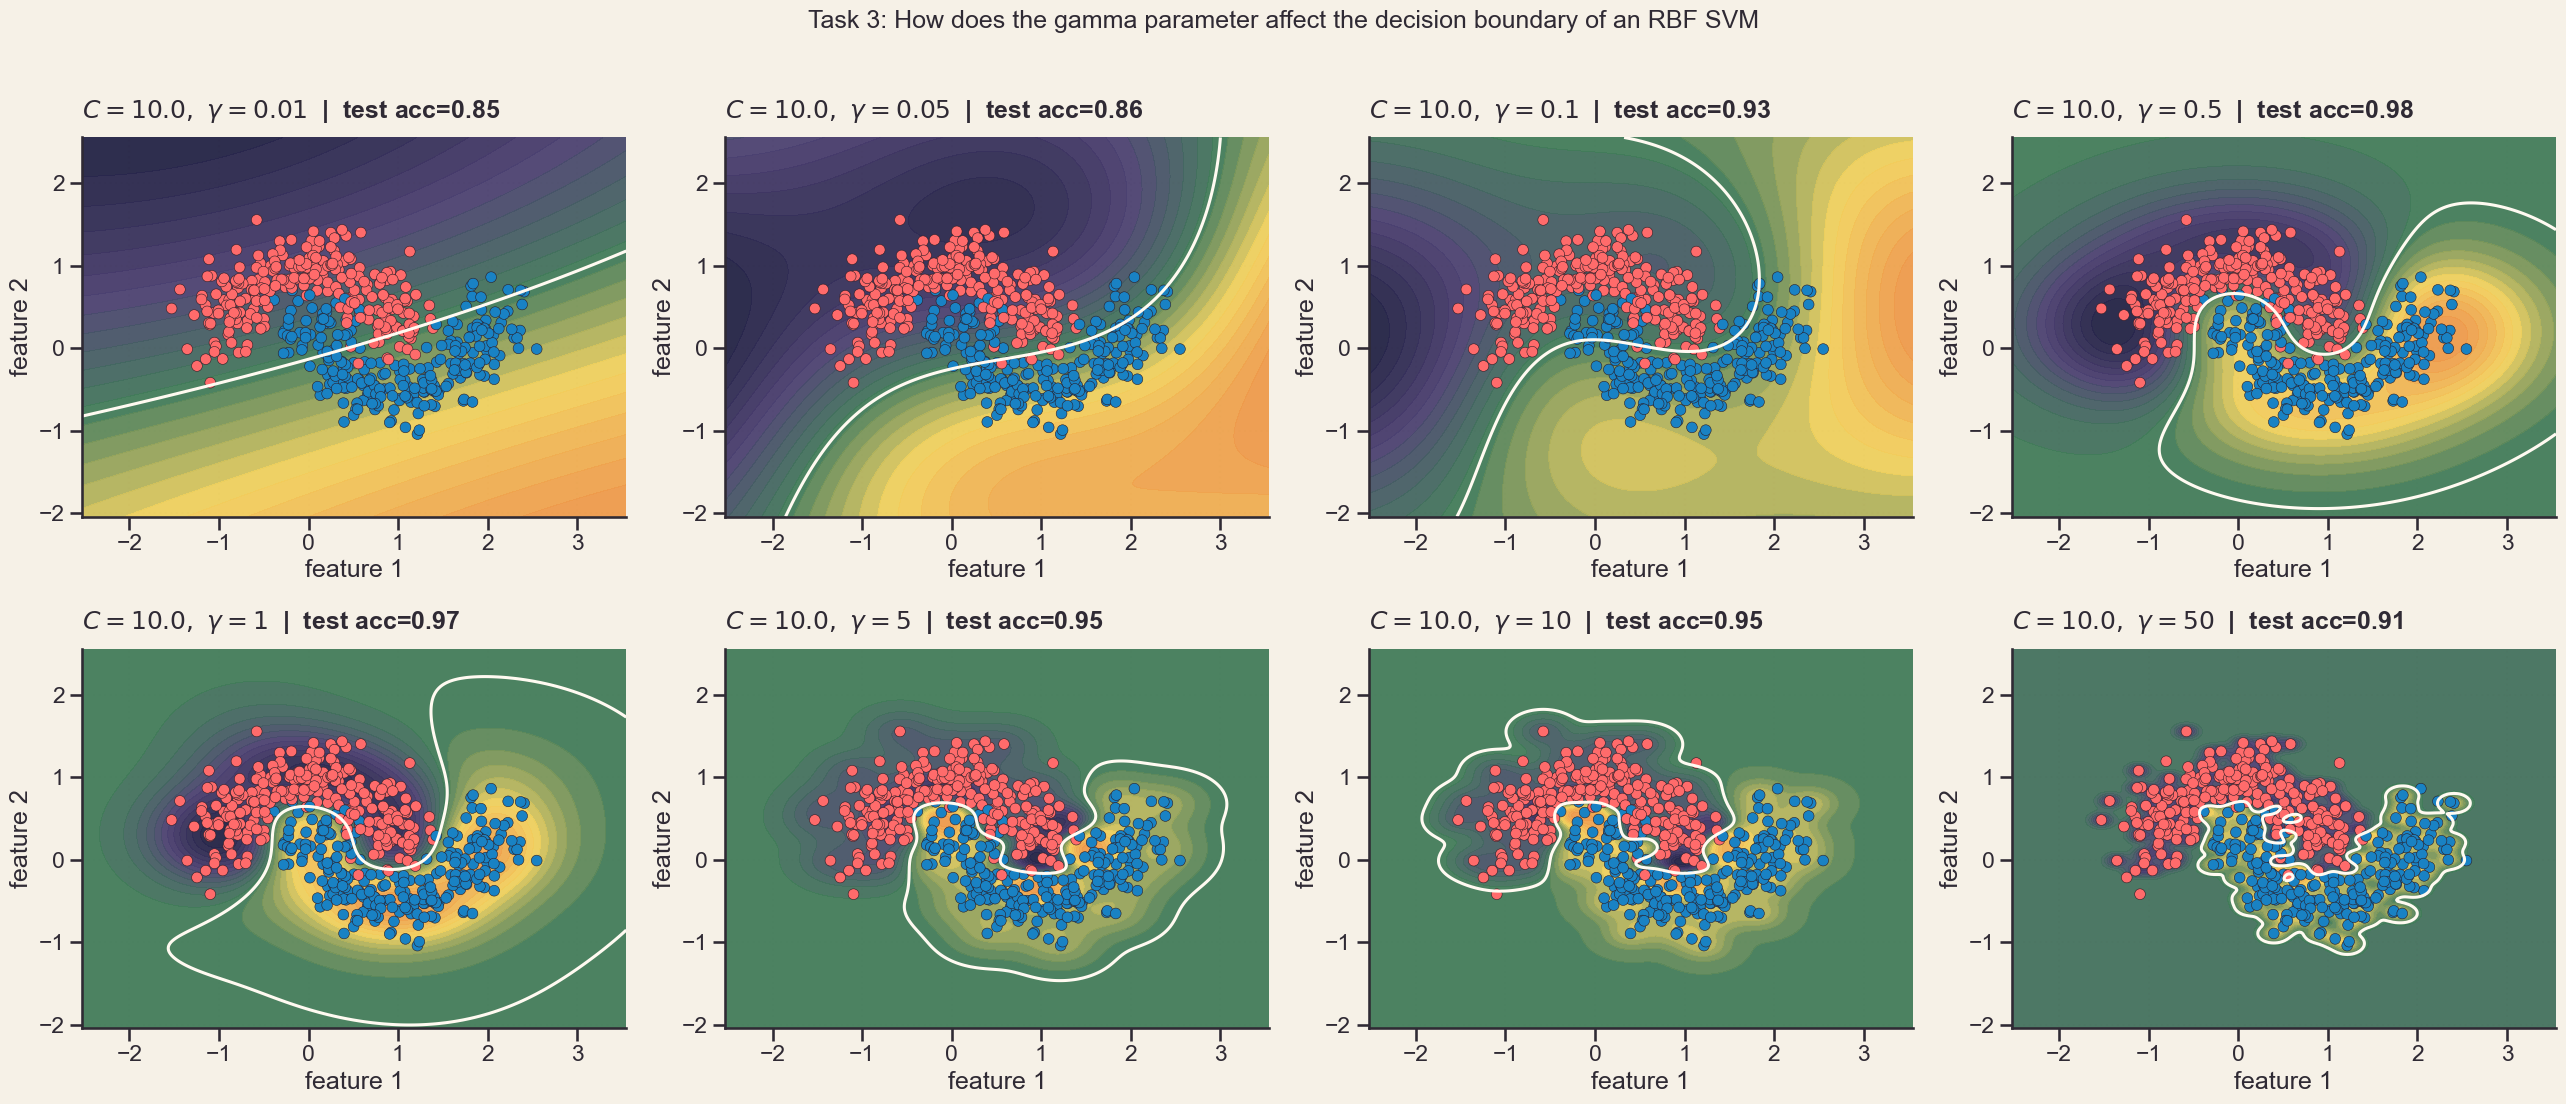

In [15]:
fig, axes = plt.subplots(2, 4, figsize=(26, 11))

for ax, gamma in zip(axes.flat, gamma_values):

    svm_rbf = Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(kernel='rbf', C=C_fixed, gamma=gamma)),
    ])
    svm_rbf.fit(X_train_m, y_train_m)

    test_acc = accuracy_score(y_test_m, svm_rbf.predict(X_test_m))

    plot_surface(ax, svm_rbf, X_moon, y_moon,
                 rf'$C={C_fixed},\ \gamma={gamma}$  |  test acc={test_acc:.2f}')

fig.suptitle('Task 3: How does the gamma parameter affect the decision boundary of an RBF SVM', y=1.01, fontsize=18)
fig.tight_layout()
plt.show()

In [16]:
X_imb, y_imb = make_classification(
    n_samples=1000,
    n_features=2,
    n_informative=2,
    n_redundant=0,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],
    random_state=42,
)

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_imb, y_imb, test_size=0.25, stratify=y_imb, random_state=42
)

balance = pd.Series(y_imb).value_counts().sort_index()
print('Number of samples in each class:')
print(balance)
print(f'\nRatio: {balance[0]/balance[1]:.1f}:1')

Number of samples in each class:
0    895
1    105
Name: count, dtype: int64

Ratio: 8.5:1


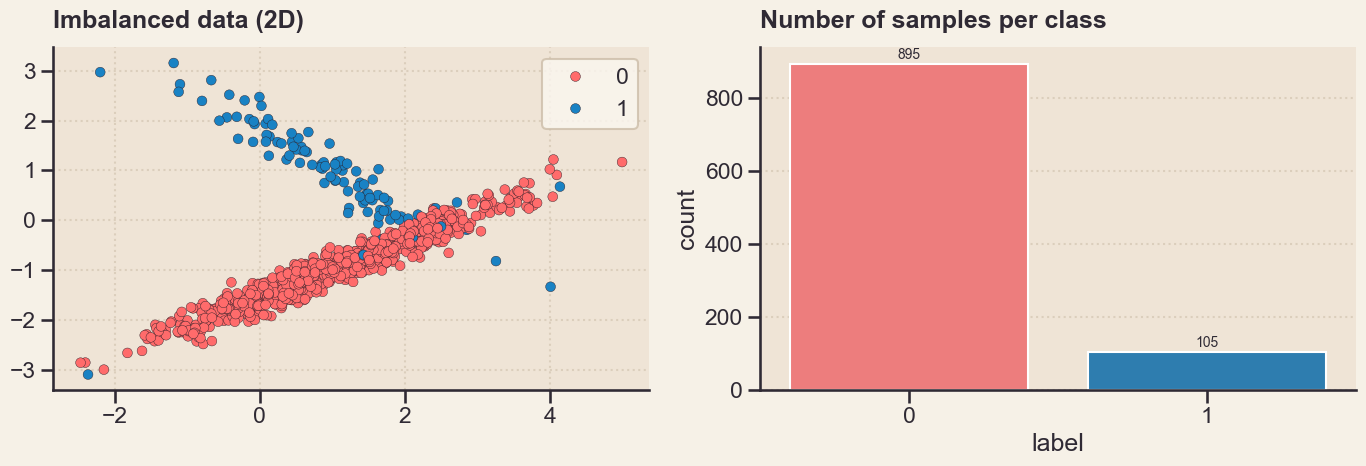

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(
    x=X_imb[:, 0], y=X_imb[:, 1], hue=y_imb,
    palette=class_colors[:2], s=50,
    edgecolor='#2b1d26', linewidth=0.3, ax=axes[0],
)
axes[0].set_title('Imbalanced data (2D)')

balance_frame = balance.reset_index()
balance_frame.columns = ['label', 'count']
sns.barplot(
    data=balance_frame, x='label', y='count',
    hue='label', palette=class_colors[:2],
    dodge=False, legend=False, ax=axes[1],
)
annotate_bars(axes[1], offset=5, fmt='{:.0f}')
axes[1].set_title('Number of samples per class')

fig.tight_layout()
plt.show()


In [18]:
model_plain = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=2000)),
])

model_balanced = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(max_iter=2000, class_weight= 'balanced')),
])

model_plain.fit(X_train_i, y_train_i)
model_balanced.fit(X_train_i, y_train_i)

pred_plain    = model_plain.predict(X_test_i)
pred_balanced = model_balanced.predict(X_test_i)

print('Training complete!')


Training complete!


In [19]:
comparison_imb = pd.concat([
    metric_frame(y_test_i, pred_plain).assign(model='Without class_weight'),
    metric_frame(y_test_i, pred_balanced).assign(model='With class_weight=balanced'),
], ignore_index=True)

print(comparison_imb.pivot(index='metric', columns='model', values='value').round(3))

model      With class_weight=balanced  Without class_weight
metric                                                     
accuracy                        0.976                 0.968
f1                              0.885                 0.818
precision                       0.885                 1.000
recall                          0.885                 0.692


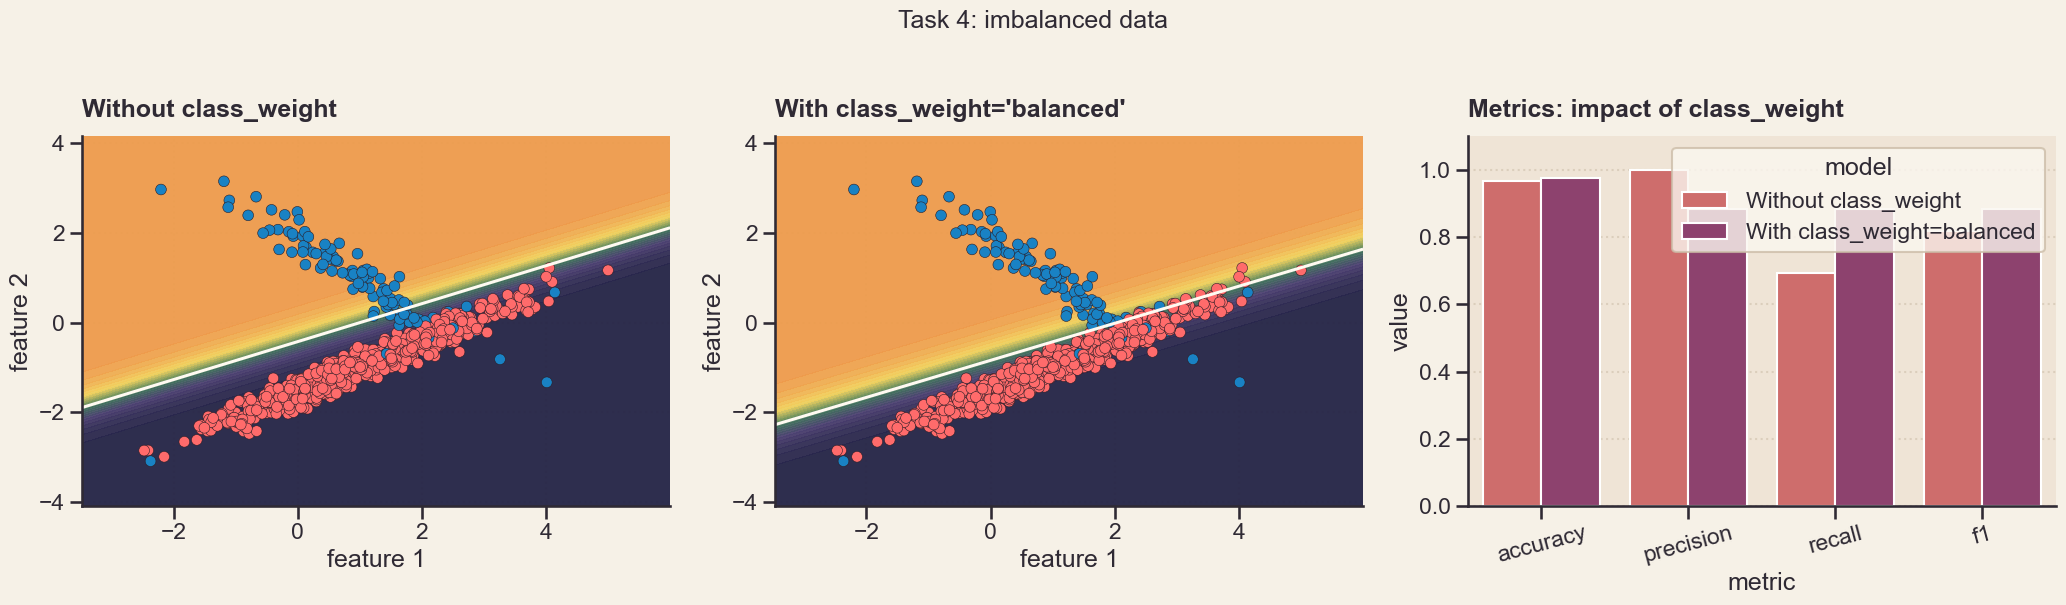

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

plot_surface(axes[0], model_plain,    X_imb, y_imb, 'Without class_weight')
plot_surface(axes[1], model_balanced, X_imb, y_imb, "With class_weight='balanced'")

# Metrics comparison
sns.barplot(
    data=comparison_imb,
    x='metric', y='value', hue='model',
    palette='flare', ax=axes[2],
)
axes[2].set_title('Metrics: impact of class_weight')
axes[2].set_ylim(0, 1.1)
axes[2].tick_params(axis='x', rotation=15)

fig.suptitle('Task 4: imbalanced data', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()

In [21]:
breast = load_breast_cancer()

X_breast = pd.DataFrame(breast.data, columns=breast.feature_names)
y_breast = pd.Series(breast.target, name='target')

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_breast, y_breast, test_size=0.25, stratify=y_breast, random_state=42
)

print(f'Dataset shape: {X_breast.shape}')
print(f'Classes: {breast.target_names}')
print(f'Class balance: {y_breast.value_counts().to_dict()}')

Dataset shape: (569, 30)
Classes: ['malignant' 'benign']
Class balance: {1: 357, 0: 212}


In [22]:
model_lsvc = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearSVC(C=1.0, max_iter=10000)),
])

model_svc_lin = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  SVC(kernel='linear', C=1.0, probability=True)),
])

In [23]:
start = time.time()
model_lsvc.fit(X_train_b, y_train_b)
time_lsvc = time.time() - start

start = time.time()
model_svc_lin.fit(X_train_b, y_train_b)
time_svc_lin = time.time() - start

print(f'LinearSVC            : {time_lsvc:.4f} sec')
print(f'SVC(kernel="linear") : {time_svc_lin:.4f} sec')
print(f'Difference is {time_svc_lin/time_lsvc:.1f} times')

LinearSVC            : 0.0036 sec
SVC(kernel="linear") : 0.0076 sec
Difference is 2.1 times


In [24]:
pred_lsvc    = model_lsvc.predict(X_test_b)
score_lsvc   = model_lsvc.decision_function(X_test_b)

pred_svc_lin  = model_svc_lin.predict(X_test_b)
proba_svc_lin = model_svc_lin.predict_proba(X_test_b)[:, 1]

comparison_svm = pd.concat([
    metric_frame(y_test_b, pred_lsvc,    score_lsvc).assign(model='LinearSVC'),
    metric_frame(y_test_b, pred_svc_lin, proba_svc_lin).assign(model='SVC(kernel=linear)'),
], ignore_index=True)

print(comparison_svm.pivot(index='metric', columns='model', values='value').round(4))

model      LinearSVC  SVC(kernel=linear)
metric                                  
accuracy      0.9720              0.9860
f1            0.9780              0.9889
precision     0.9674              0.9889
recall        0.9889              0.9889
roc_auc       0.9939              0.9973


In [25]:
summary = pd.DataFrame([
    {
        'model': 'LinearSVC',
        'train_time_sec': round(time_lsvc, 4),
        'accuracy': accuracy_score(y_test_b, pred_lsvc),
        'f1':       f1_score(y_test_b, pred_lsvc),
        'roc_auc':  roc_auc_score(y_test_b, score_lsvc),
    },
    {
        'model': 'SVC(kernel=linear)',
        'train_time_sec': round(time_svc_lin, 4),
        'accuracy': accuracy_score(y_test_b, pred_svc_lin),
        'f1':       f1_score(y_test_b, pred_svc_lin),
        'roc_auc':  roc_auc_score(y_test_b, proba_svc_lin),
    },
])

summary.round(4)

,model,train_time_sec,accuracy,f1,roc_auc
0,LinearSVC,0.0036,0.972,0.9780,0.9939
1,SVC(kernel=linear),0.0076,0.986,0.9889,0.9973


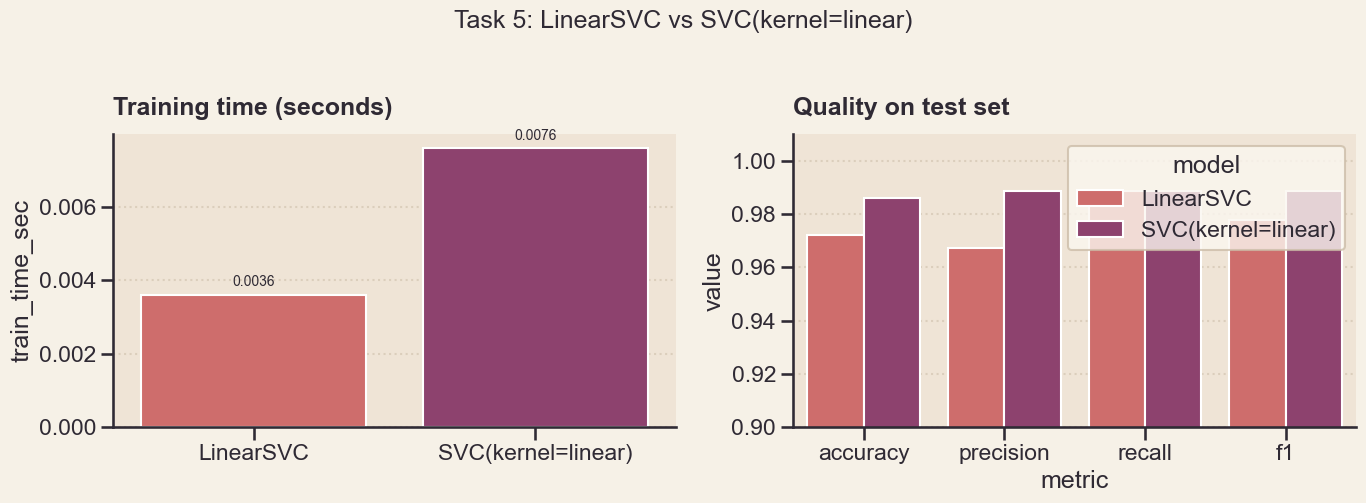

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    data=summary, x='model', y='train_time_sec',
    hue='model', palette='flare',
    dodge=False, legend=False, ax=axes[0],
)
annotate_bars(axes[0], fmt='{:.4f}')
axes[0].set_title('Training time (seconds)')
axes[0].set_xlabel('')

metrics_melt = comparison_svm[comparison_svm['metric'] != 'roc_auc']
sns.barplot(
    data=metrics_melt, x='metric', y='value', hue='model',
    palette='flare', ax=axes[1],
)
axes[1].set_ylim(0.9, 1.01)
axes[1].set_title('Quality on test set')

fig.suptitle('Task 5: LinearSVC vs SVC(kernel=linear)', y=1.02, fontsize=18)
fig.tight_layout()
plt.show()